# Exp 8: all-fish accumulation-evidence raster

This notebook is the maintained all-fish raster workflow for `Exp_8_accumulation_ev`. It keeps the reusable `src` helper flow from the Exp 1 notebook: load and validate the selected cohort, build an all-fish z-score raster, then render mean traces, left/right active-neuron diagnostics, motion-period counts, and lifetime sparseness.

The Exp 8 settings below were checked against the local experiment folders, four-block logs, trajectory timing, and the maintained several-fish configuration. Edit only `USER_SETTINGS` and `REPORT_SETTINGS`.


In [76]:
# Cell 01 - Setup
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott
plott = importlib.reload(plott)
import src.reusable_several_fish as rsf
rsf = importlib.reload(rsf)


In [77]:
# Cell 02 - Exp 8 settings
# IDs, cohort, blocks, and timing were validated from the local Exp 8 data/configuration.
USER_SETTINGS = {
    'experiment_name': 'Exp_8_accumulation_ev',
    'analysis_label': 'Exp 8 accumulation evidence',
    'data_base': Path(r'D:\Alejandro\Data'),
    # left = 10, 11, right = 4, 5, 7, both = 2, 3, 9
    # Maintained responsive Exp 8 cohort; L800_f01, f06, and f08 are excluded as bad-signal recordings.
    'fish_ids': ['L800_f02', 'L800_f03', 'L800_f09','L800_f04', 'L800_f05', 'L800_f07'],
    # Every trajectory occurs once per B1--B4 block (four repetitions per stimulus).
    'selected_blocks': [f'B{number}' for number in range(1, 5)],
    'verbose_loading': False,
    # 2 Hz acquisition and the 5 s / 25 s trial-alignment window are the maintained Exp 8 settings.
    # motion_onset_s is the canonical 8 s stimulus-program onset; exact per-trajectory markers come from the loader.
    'timing': {'fps_2p': 2.0, 't_pre_s': 5.0, 't_post_s': 30.0, 'motion_onset_s': 8.0, 'tau_s': 6.0},
    # Validated loader mapping, ordered left then right: base, segment 2, segment 1, random segment 1,
    # segments 1/3/5, rocking, five-position flicker, one-position flicker.
    #'stim_order': [5, 4, 3, 2, 1, 8, 7, 6, 16, 15, 14, 13, 12, 11, 10, 9],
    'stim_order': [5, 4, 3, 2, 1, 8, 7, 6, 16, 15, 14, 13, 12, 11, 10, 9],
    'combine_mode': 'mean',
    'trace_type': 'zscore',
    'raster_sort_mode':  'left_right_index',
    'left_control': 5,   # LeB
    'right_control': 16, # RiB
}

REPORT_SETTINGS = {
    'save_report': False,
    'run_label': 'exp8_accumulation_evidence_all_fish_raster',
    'report_format': 'html',
    'export_notebook': True,
    'fallback_to_html': True,
    'comments': 'Enable only after reviewing the Exp 8 figures.',
}


In [78]:
# Cell 03 - Load the selected Exp 8 cohort and validate every configured stimulus ID.
raster_inputs = rsf.load_and_preflight_fish_raster_inputs(USER_SETTINGS)
globals().update(raster_inputs)
stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(stimuli_names=stimuli_names)
print('Detected Exp 8 stimulus map:', stimuli_id_map)


Detected Exp 8 stimulus map: {'LeBseg135': 1, 'LeBseg1rnd': 2, 'LeBseg1': 3, 'LeBseg2': 4, 'LeB': 5, 'Leflick1': 6, 'Leflick5': 7, 'LeRock': 8, 'RiBflick1': 9, 'RiBflick5': 10, 'RiBrock': 11, 'RiBseg135': 12, 'RiBseg1rnd': 13, 'RiBseg1': 14, 'RiBseg2': 15, 'RiB': 16}


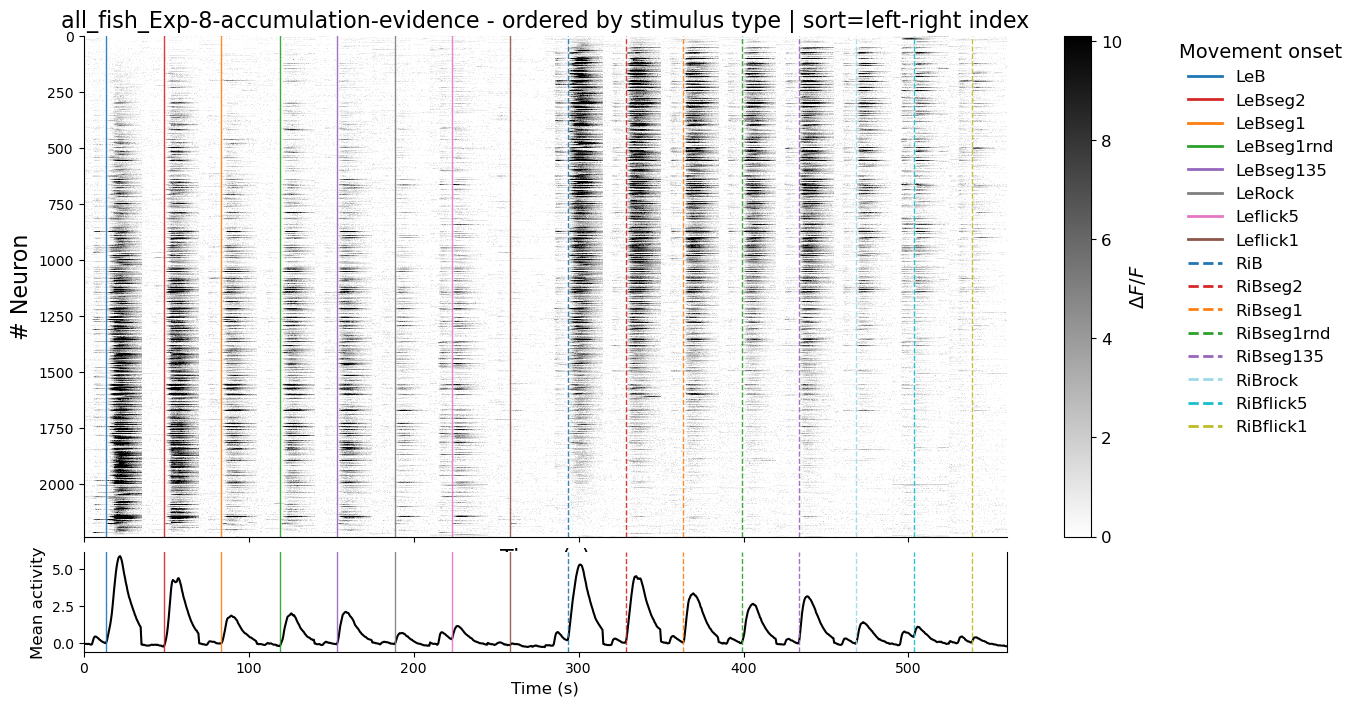

In [79]:
# Cell 04 - All-fish z-score raster.
FIGSIZE = (13, 8)
raster_result = rsf.build_all_fish_raster_figure(
    all_fish_data, fish_ids, stim_order, reference_fish, timing, settings,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)
flat_matrix_all_fish = raster_result['flat_matrix_all_fish']
plt.show()


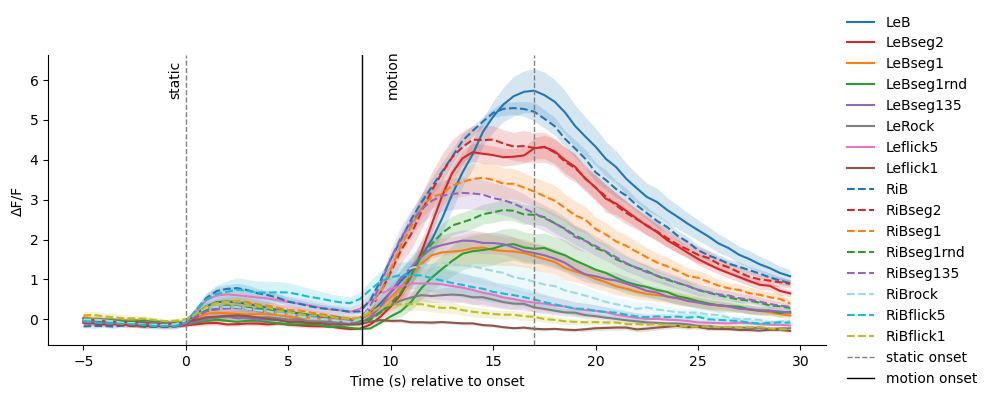

In [80]:
# Cell 05 - Mean z-score traces in the configured Exp 8 stimulus order.
FIGSIZE = (10, 4)
mean_trace_result = rsf.build_plot_all_fish_mean_zscore_traces(
    all_fish_data, fish_ids, stim_order, reference_fish, timing,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)


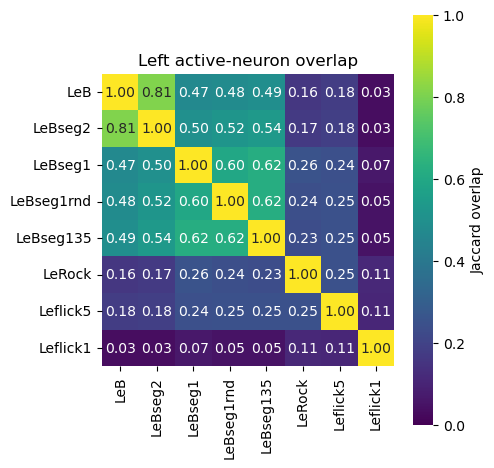

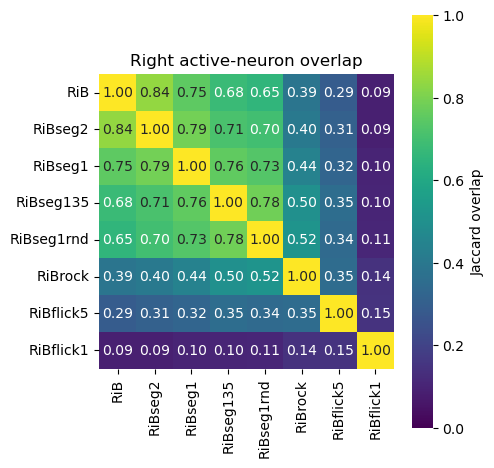

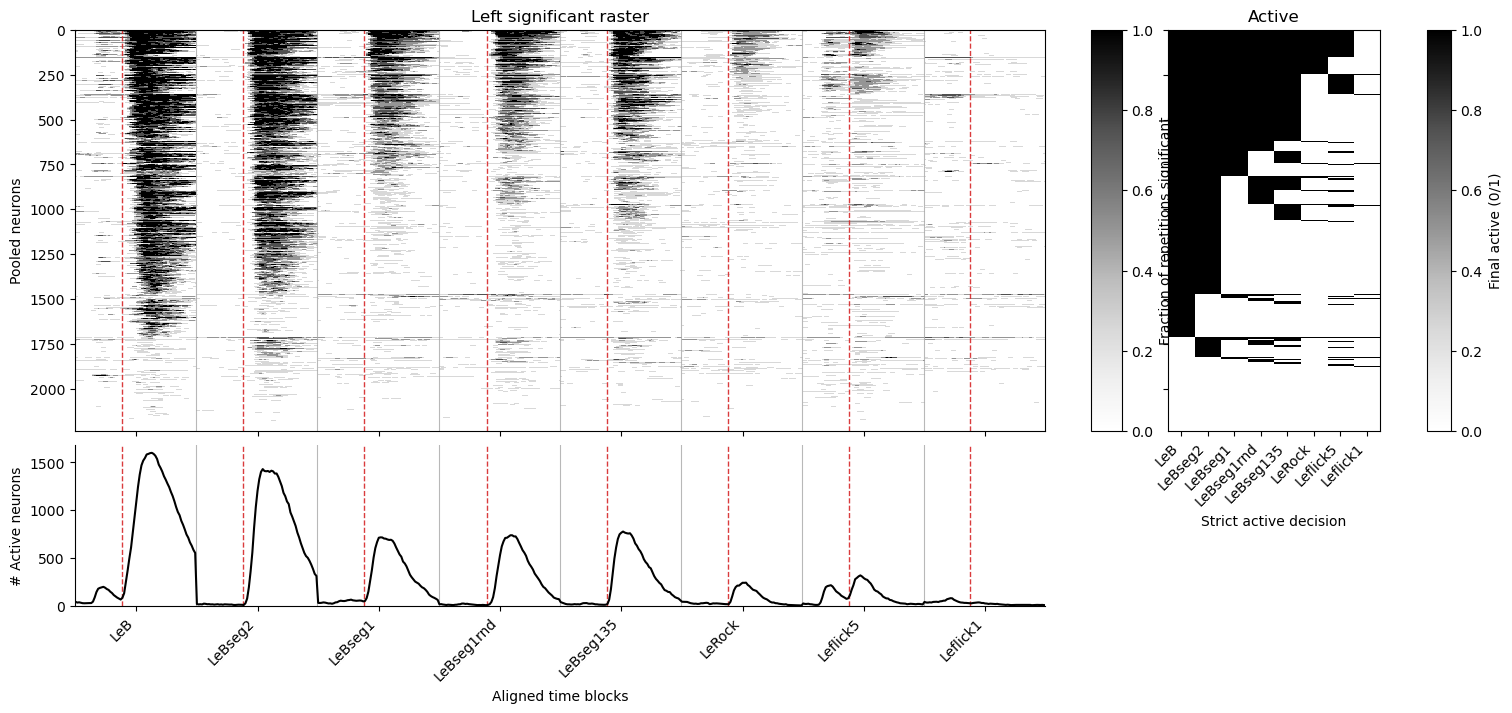

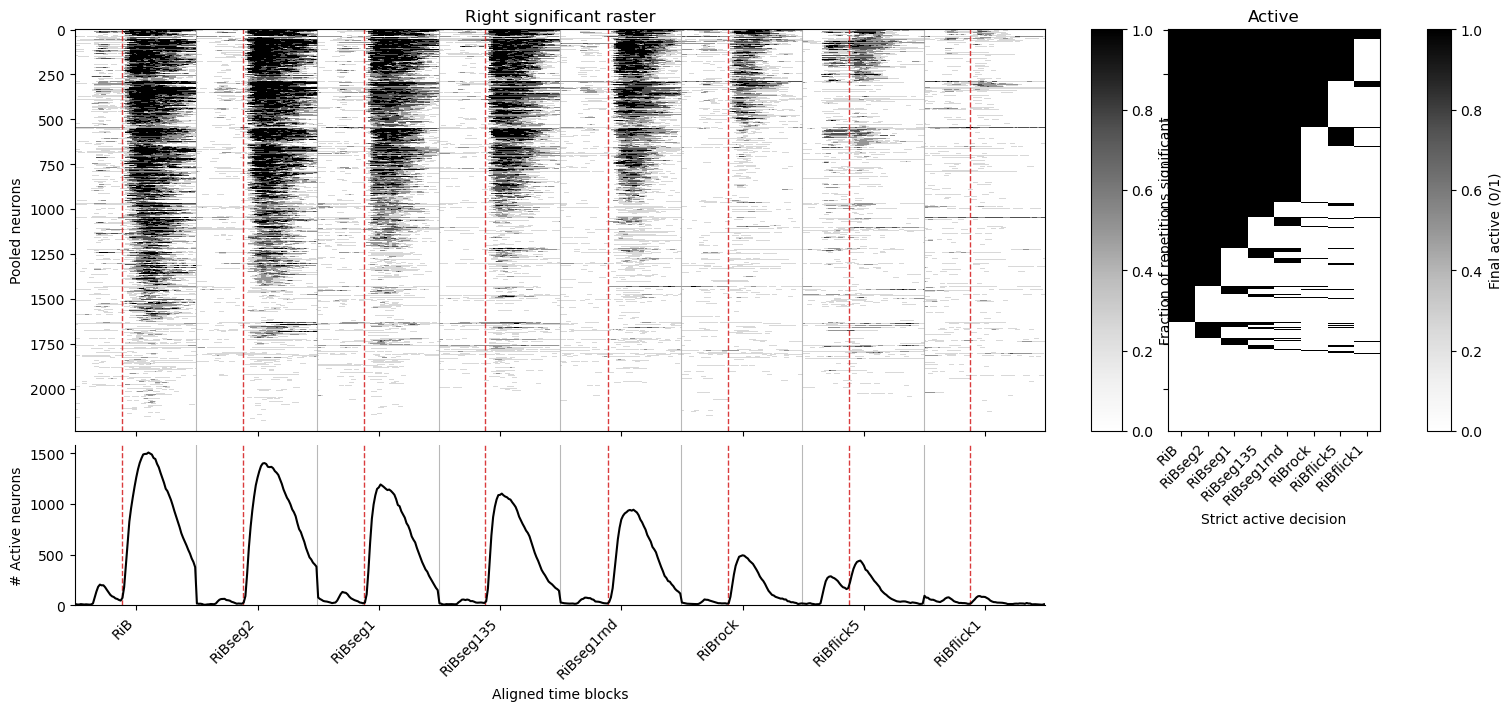

In [81]:
# Cell 06 - Left/right active-neuron overlap and significant-raster diagnostics.
OVERLAP_FIGSIZE = (5, 5)
RASTER_FIGSIZE = (16, 8)
OVERLAP_STIMULI = {
    'left': [5, 4, 3, 2, 1, 8, 7, 6],
    'right': [16, 15, 14, 12, 13, 11, 10, 9],
}
# Build shared overlap data first; draw rasters here from the reloaded plotting module.
overlap_results = rsf.plot_left_right_active_overlap_diagnostics(
    all_fish_data, fish_ids, reference_fish, timing, OVERLAP_STIMULI,
    motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    show_overlap=True, show_significant_raster=False, overlap_figsize=OVERLAP_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE,
)
for side in ('left', 'right'):
    diagnostic_data = overlap_results[side]
    diagnostic = diagnostic_data['active_trace_diagnostic']
    if diagnostic['trace_matrix'].shape[0] == 0:
        print(f'No active neurons passed the {side} settings.')
        continue
    plott.plot_active_trace_decision_diagnostic(
        diagnostic,
        fps_2p=timing['fps_2p'],
        stimuli_durations=reference_fish['stimuli_durations'],
        t_pre_s=timing['t_pre_s'],
        sort_mode=None,
        neuron_order=diagnostic_data['diagnostic_neuron_order'],
        trace_cmap='Greys',
        trace_title=f'{side.capitalize()} significant raster',
        show_active_count_trace=True,
        active_count_threshold=0.5,
        active_count_color='black',
        active_count_ylabel='# Active neurons',
        active_count_height_ratio=2.4,
        figsize=RASTER_FIGSIZE,
    )
    plt.show()


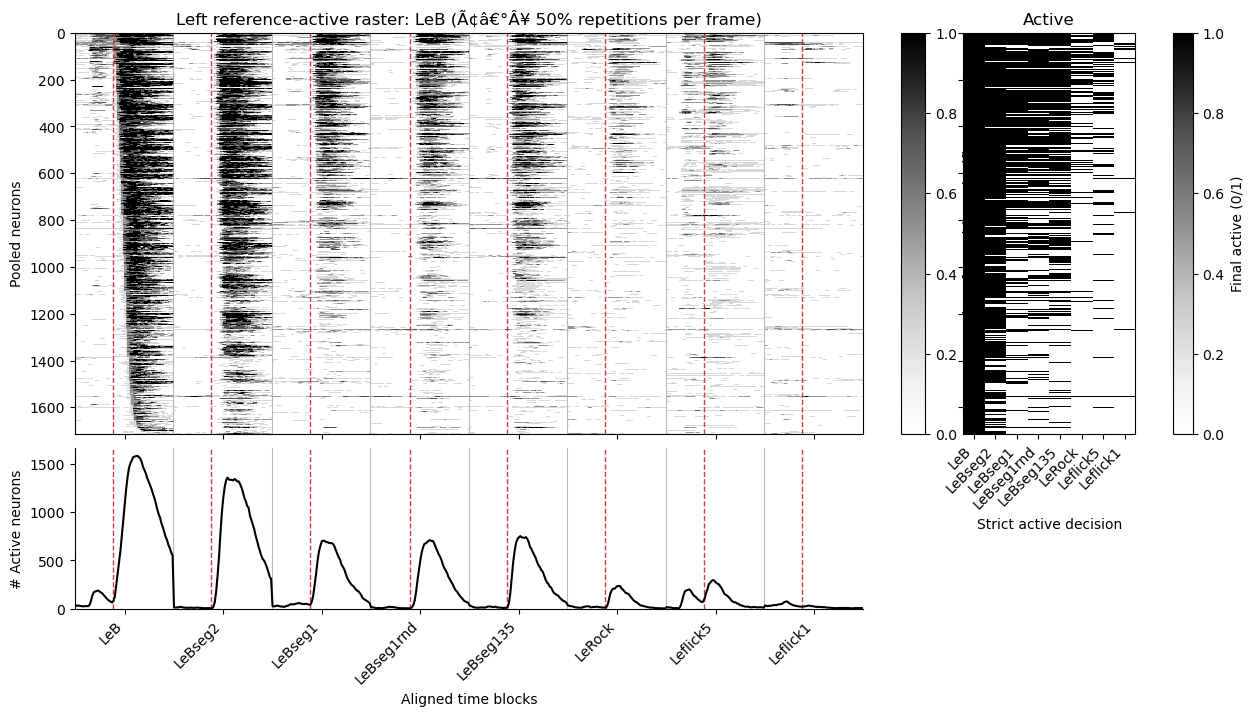

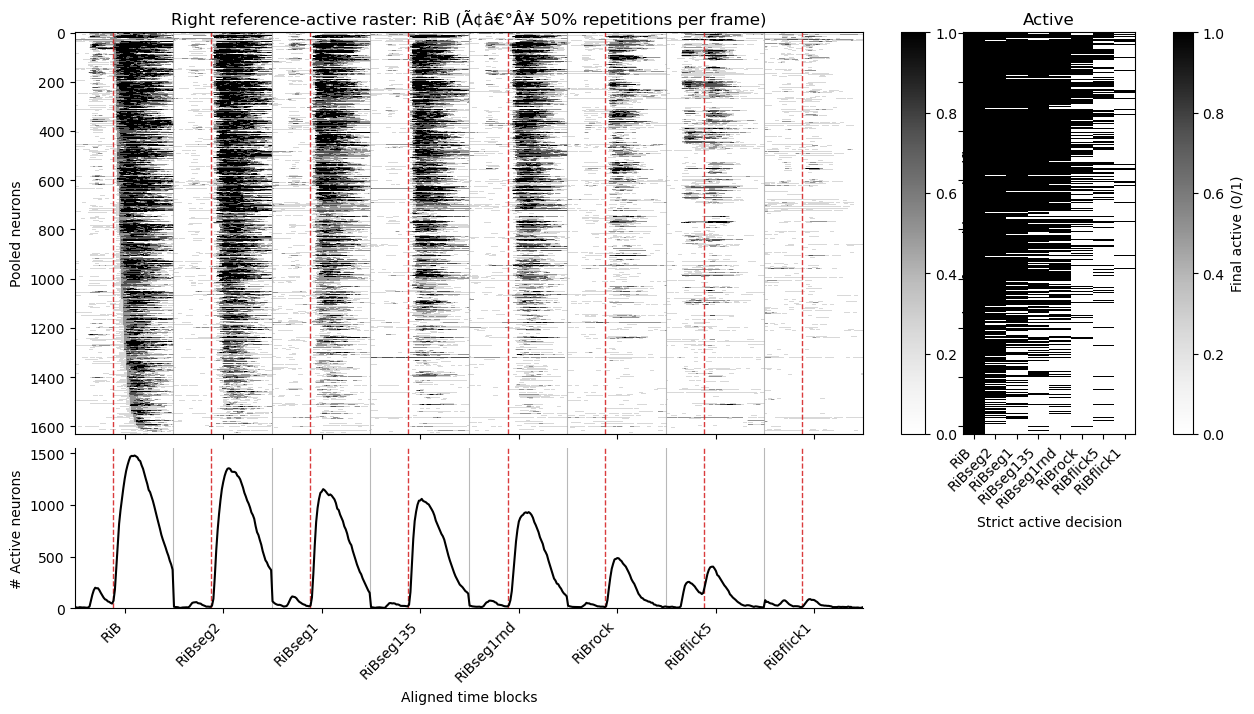

In [92]:
# Cell 07 - Reference-active significant rasters, ordered by post-motion onset.
# Edit the reference and displayed stimuli independently; keep left/right groups separate.
REFERENCE_RASTER_SETTINGS = {
    'left': {'reference_stimulus': 5, 'plot_stimuli': [5, 4, 3, 2, 1, 8, 7, 6]},  # LeB
    'right': {'reference_stimulus': 16, 'plot_stimuli': [16, 15, 14,12, 13, 11, 10, 9]},  # RiB
}
min_active_reps = 0.50  # Fraction of repetitions significantly active at one frame.

if not 0 < min_active_reps <= 1:
    raise ValueError('min_active_reps must be in (0, 1].')

reference_and_plot_stimuli = list(dict.fromkeys(
    [group['reference_stimulus'] for group in REFERENCE_RASTER_SETTINGS.values()]
    + [stimulus for group in REFERENCE_RASTER_SETTINGS.values() for stimulus in group['plot_stimuli']]
))
# These are the same strict activity decisions used by Cell 06.
reference_active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data, fish_ids=fish_ids, stim_order=reference_and_plot_stimuli,
    fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
    motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    active_fraction_threshold=0.10, min_epoch_s=1.0, min_active_reps=2,
    expected_reps=4, require_expected_reps=True,
)

for side, group in REFERENCE_RASTER_SETTINGS.items():
    selection = at.resolve_selected_stimuli(
        group['plot_stimuli'], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_selection = at.resolve_selected_stimuli(
        [group['reference_stimulus']], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_id = reference_selection['stimulus_ids'][0]
    reference_label = reference_selection['stimulus_labels'][0]
    diagnostic = mfa.build_pooled_active_trace_diagnostic(
        all_fish_data=all_fish_data, active_matrices=reference_active_matrices, fish_ids=fish_ids,
        stim_order=selection['stimulus_ids'], combine_mode='mean',
        trial_key='trial_aligned_traces_raster',
    )
    activity_onsets = []
    for fish_id in fish_ids:
        fish = all_fish_data[fish_id]
        reference_key = reference_id if reference_id in fish['trial_aligned_traces_raster'] else str(reference_id)
        reference_raster = np.asarray(fish['trial_aligned_traces_raster'][reference_key], dtype=bool)
        duration = fish['stimuli_durations'][reference_label]
        motion_frame = int(np.clip(
            round((timing['t_pre_s'] + duration['static_before_sec']) * timing['fps_2p']),
            0, reference_raster.shape[1] - 1,
        ))
        active_by_frame = reference_raster.mean(axis=2) >= min_active_reps
        post_motion = active_by_frame[:, motion_frame:]
        first_active = np.full(reference_raster.shape[0], np.inf)
        has_active_frame = post_motion.any(axis=1)
        first_active[has_active_frame] = motion_frame + post_motion[has_active_frame].argmax(axis=1)
        activity_onsets.append(first_active)

    activity_onsets = np.concatenate(activity_onsets)
    reference_active = diagnostic['row_metadata'].apply(
        lambda row: bool(reference_active_matrices[row['fish_id']].loc[row['neuron_id'], reference_id]), axis=1
    ).to_numpy()
    keep_rows = np.flatnonzero(reference_active)
    if keep_rows.size == 0:
        print(f'No neurons are strictly active for {side} reference {reference_label}.')
        continue
    selected_diagnostic = {
        **diagnostic,
        'trace_matrix': diagnostic['trace_matrix'][keep_rows],
        'decision_matrix': diagnostic['decision_matrix'][keep_rows],
        'row_metadata': diagnostic['row_metadata'].iloc[keep_rows].reset_index(drop=True),
    }
    onset_order = np.argsort(activity_onsets[keep_rows], kind='stable')
    plott.plot_active_trace_decision_diagnostic(
        selected_diagnostic, fps_2p=timing['fps_2p'], stimuli_durations=reference_fish['stimuli_durations'],
        t_pre_s=timing['t_pre_s'], sort_mode=None, neuron_order=onset_order, trace_cmap='Greys',
        trace_title=(f'{side.capitalize()} reference-active raster: {reference_label} '
                     f'(Ã¢â€°Â¥ {min_active_reps:.0%} repetitions per frame)'),
        show_active_count_trace=True, active_count_threshold=0.5, active_count_color='black',
        active_count_ylabel='# Active neurons', active_count_height_ratio=2.4, figsize=RASTER_FIGSIZE,
    )
    plt.show()

In [ ]:
# Cell 08 - Recruitment by reference-onset time.
# This uses the same strict active-neuron decisions as the reference-active raster.
REFERENCE_ONSET_TIME_BIN_S = 1.0  # Editable: width of measured post-motion onset-time bins.
REFERENCE_ONSET_MAX_TIME_S = 9.0  # Editable upper limit; bins span 0 s up to, but not including, this time.
RECRUITMENT_SIDES = ('right',)  # RiB by default; use ('left', 'right') to also plot LeB.

if REFERENCE_ONSET_TIME_BIN_S <= 0:
    raise ValueError('REFERENCE_ONSET_TIME_BIN_S must be positive.')
if REFERENCE_ONSET_MAX_TIME_S <= 0:
    raise ValueError('REFERENCE_ONSET_MAX_TIME_S must be positive.')

reference_onset_recruitment = {}
for side in RECRUITMENT_SIDES:
    if side not in REFERENCE_RASTER_SETTINGS:
        raise KeyError(f'Unknown side {side!r}; choose from {tuple(REFERENCE_RASTER_SETTINGS)}.')
    group = REFERENCE_RASTER_SETTINGS[side]
    selection = at.resolve_selected_stimuli(
        group['plot_stimuli'], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_selection = at.resolve_selected_stimuli(
        [group['reference_stimulus']], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_id = reference_selection['stimulus_ids'][0]
    reference_label = reference_selection['stimulus_labels'][0]

    pooled_rows = []
    for fish_id in fish_ids:
        fish = all_fish_data[fish_id]
        reference_key = reference_id if reference_id in fish['trial_aligned_traces_raster'] else str(reference_id)
        reference_raster = np.asarray(fish['trial_aligned_traces_raster'][reference_key], dtype=bool)
        duration = fish['stimuli_durations'][reference_label]
        motion_frame = int(np.clip(
            round((timing['t_pre_s'] + duration['static_before_sec']) * timing['fps_2p']),
            0, reference_raster.shape[1] - 1,
        ))
        active_by_frame = reference_raster.mean(axis=2) >= min_active_reps
        post_motion = active_by_frame[:, motion_frame:]
        first_active = np.full(reference_raster.shape[0], np.inf)
        has_active_frame = post_motion.any(axis=1)
        first_active[has_active_frame] = motion_frame + post_motion[has_active_frame].argmax(axis=1)

        active_matrix = reference_active_matrices[fish_id]
        reference_column = reference_id if reference_id in active_matrix.columns else str(reference_id)
        for neuron_id in np.flatnonzero(active_matrix[reference_column].to_numpy(dtype=bool)):
            if not np.isfinite(first_active[neuron_id]):
                continue  # A strict reference decision without a measurable post-motion onset.
            row = {
                'fish_id': fish_id, 'neuron_id': neuron_id, 'onset_frame': first_active[neuron_id],
                'onset_time_s': (first_active[neuron_id] - motion_frame) / timing['fps_2p'],
            }
            for stimulus_id, stimulus_label in zip(selection['stimulus_ids'], selection['stimulus_labels']):
                column = stimulus_id if stimulus_id in active_matrix.columns else str(stimulus_id)
                row[stimulus_label] = bool(active_matrix.iloc[neuron_id][column])
            pooled_rows.append(row)

    pooled_rows = pd.DataFrame(pooled_rows)
    if pooled_rows.empty:
        print(f'No reference-active neurons with measurable post-motion onsets for {side} ({reference_label}).')
        continue

    pooled_rows = pooled_rows.loc[
        (pooled_rows['onset_time_s'] >= 0) & (pooled_rows['onset_time_s'] < REFERENCE_ONSET_MAX_TIME_S)
    ].sort_values('onset_time_s', kind='stable').reset_index(drop=True)
    if pooled_rows.empty:
        print(f'No {reference_label}-active neurons have onsets between 0 and {REFERENCE_ONSET_MAX_TIME_S:g} s.')
        continue
    onset_bin_count = int(np.ceil(REFERENCE_ONSET_MAX_TIME_S / REFERENCE_ONSET_TIME_BIN_S))
    pooled_rows['onset_bin'] = np.floor(
        pooled_rows['onset_time_s'] / REFERENCE_ONSET_TIME_BIN_S
    ).astype(int)
    onset_bin_indices = np.arange(onset_bin_count)
    onset_bin_starts_s = onset_bin_indices * REFERENCE_ONSET_TIME_BIN_S
    onset_bin_ends_s = np.minimum(onset_bin_starts_s + REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    onset_bin_centers_s = (onset_bin_starts_s + onset_bin_ends_s) / 2
    onset_bin_labels = [
        f'{start_s:g}–{end_s:g}' for start_s, end_s in zip(onset_bin_starts_s, onset_bin_ends_s)
    ]
    fraction_active = pooled_rows.groupby('onset_bin')[selection['stimulus_labels']].mean().reindex(
        onset_bin_indices
    )
    neurons_per_bin = pooled_rows.groupby('onset_bin').size().reindex(onset_bin_indices, fill_value=0)
    reference_onset_recruitment[side] = {
        'reference_label': reference_label, 'neurons': pooled_rows, 'fraction_active': fraction_active,
        'onset_bin_starts_s': onset_bin_starts_s, 'onset_bin_centers_s': onset_bin_centers_s,
        'onset_bin_labels': onset_bin_labels,
        'neurons_per_bin': neurons_per_bin,
    }

    fig, (line_ax, heatmap_ax, count_ax) = plt.subplots(1, 3, figsize=(20, 4.5), constrained_layout=True)
    for stimulus_label in selection['stimulus_labels']:
        line_ax.plot(
            onset_bin_centers_s, fraction_active[stimulus_label], marker='o', linewidth=2,
            color=stimuli_colors.get(stimulus_label), label=stimulus_label,
        )
    line_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel='Fraction of neurons active',
        title=f'{side.capitalize()}: recruitment by {REFERENCE_ONSET_TIME_BIN_S:g}-s {reference_label}-onset bins',
        xticks=onset_bin_starts_s, ylim=(0, 1),
    )
    line_ax.set_xlim(-0.05 * REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    line_ax.legend(title='Stimulus', frameon=False, fontsize=8, ncol=2,
                   bbox_to_anchor=(0.5, -0.22), loc='upper center')

    heatmap_values = fraction_active.T.to_numpy(dtype=float)
    image = heatmap_ax.imshow(heatmap_values, aspect='auto', vmin=0, vmax=1, cmap='viridis')
    heatmap_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel='Stimulus',
        title='Fraction active', xticks=np.arange(onset_bin_count),
        xticklabels=onset_bin_labels,
        yticklabels=selection['stimulus_labels'],
    )
    fig.colorbar(image, ax=heatmap_ax, label='Fraction active')

    count_ax.bar(
        onset_bin_centers_s, neurons_per_bin.to_numpy(),
        width=onset_bin_ends_s - onset_bin_starts_s, align='center', color='0.25', edgecolor='white',
    )
    count_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel=f'# {reference_label}-active neurons',
        title=f'{reference_label} neurons per onset-time bin', xticks=onset_bin_starts_s,
    )
    count_ax.set_xlim(-0.05 * REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    plt.show()
    display(fraction_active.T)


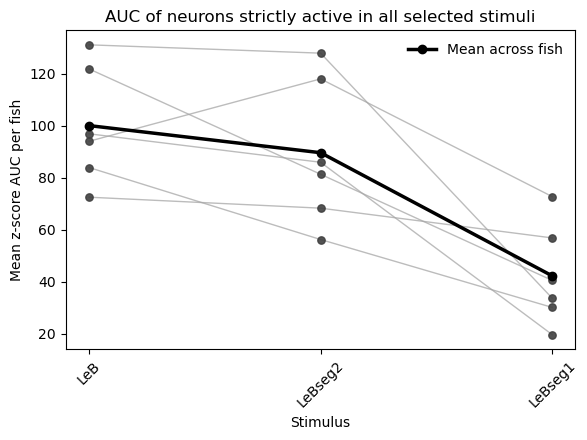

,fish_id,stimulus,mean_auc,n_shared_active_neurons
0,L800_f02,LeB,72.442560,262
1,L800_f02,LeBseg2,68.224376,262
2,L800_f02,LeBseg1,56.780903,262
3,L800_f03,LeB,83.850204,106
4,L800_f03,LeBseg2,56.164286,106
5,L800_f03,LeBseg1,30.058669,106
6,L800_f09,LeB,121.776977,240
7,L800_f09,LeBseg2,81.258520,240
8,L800_f09,LeBseg1,40.442383,240
9,L800_f04,LeB,93.942330,58


In [83]:
# Cell 08 - Mean AUC comparison for neurons strictly active in every selected stimulus.
# Edit this list (IDs or names) to choose the shared-active comparison.
AUC_COMPARISON_STIMULI = [5, 4, 3]

auc_selection = at.resolve_selected_stimuli(
    AUC_COMPARISON_STIMULI, stimuli_id_map=reference_fish['stimuli_id_map'],
    available_stimuli=reference_fish['trial_aligned_traces_z_core'].keys(),
)
auc_active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data, fish_ids=fish_ids, stim_order=auc_selection['stimulus_ids'],
    fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
    motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    active_fraction_threshold=0.10, min_epoch_s=1.0, min_active_reps=2,
    expected_reps=4, require_expected_reps=True,
)

auc_by_fish = []
for fish_id in fish_ids:
    fish = all_fish_data[fish_id]
    shared_active = auc_active_matrices[fish_id].loc[:, auc_selection['stimulus_ids']].all(axis=1).to_numpy()
    if not shared_active.any():
        print(f'{fish_id}: no neurons are strictly active in every selected stimulus.')
        continue
    # Use the standard per-neuron z-score AUC already defined for this aligned data.
    auc_matrix = mfa.build_zscore_response_matrix_for_fish(
        fish['trial_aligned_traces_z_core'], auc_selection['stimulus_ids'], fish['stimuli_durations'],
        stimuli_id_map=fish['stimuli_id_map'], kept_neuron_indices=fish['kept_neuron_indices'],
        fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
        motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    )
    auc_by_fish.append(pd.DataFrame({
        'fish_id': fish_id, 'stimulus': auc_selection['stimulus_labels'],
        'mean_auc': auc_matrix.loc[shared_active, auc_selection['stimulus_labels']].mean(axis=0).to_numpy(),
        'n_shared_active_neurons': int(shared_active.sum()),
    }))

shared_active_auc_summary = pd.concat(auc_by_fish, ignore_index=True) if auc_by_fish else pd.DataFrame()
if shared_active_auc_summary.empty:
    print('No fish contributed shared-active neurons for the selected stimuli.')
else:
    fig, ax = plt.subplots(figsize=(max(6, len(auc_selection['stimulus_labels']) * 1.1), 4.5))
    stimulus_positions = np.arange(len(auc_selection['stimulus_labels']))
    for fish_id, fish_values in shared_active_auc_summary.groupby('fish_id', sort=False):
        values = fish_values.set_index('stimulus').loc[auc_selection['stimulus_labels'], 'mean_auc'].to_numpy()
        ax.plot(stimulus_positions, values, color='0.65', linewidth=1, alpha=0.75, zorder=1)
        ax.scatter(stimulus_positions, values, color='0.25', s=28, alpha=0.9, zorder=2)
    mean_auc = shared_active_auc_summary.groupby('stimulus')['mean_auc'].mean().reindex(auc_selection['stimulus_labels'])
    ax.plot(stimulus_positions, mean_auc, color='black', marker='o', linewidth=2.5, label='Mean across fish', zorder=3)
    ax.set(xticks=stimulus_positions, xticklabels=auc_selection['stimulus_labels'],
           ylabel='Mean z-score AUC per fish', xlabel='Stimulus',
           title='AUC of neurons strictly active in all selected stimuli')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    display(shared_active_auc_summary)

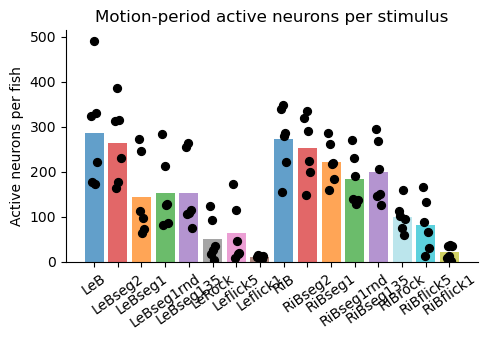

In [84]:
# Cell 09 - Motion-period active neurons per stimulus; each black point is one fish.
# The helper deliberately creates no fish legend, and receives this settings-cell order unchanged.
FIGSIZE = (5, 3.5)
motion_active_result = rsf.plot_motion_active_neuron_counts(
    all_fish_data, fish_ids, reference_fish, timing, stim_order, stimuli_colors,
    figsize=FIGSIZE, motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
)
active_neuron_counts = motion_active_result['counts']


## Per-fish active-neuron AUC decomposition

For `RiBseg1 ? RiBseg2` and `RiBseg2 ? RiB`, this section reuses Cell 09's strict motion-period active-neuron decisions and Cell 08's per-neuron z-score AUC. Raw AUC is **total integrated z-score activity** over each stimulus-specific response window; duration-normalized AUC divides each neuron's AUC by that window's integrated time span. Percent contributions are expressed relative to the corresponding total change.


In [85]:
# Cell 10 - Per-fish AUC decomposition from Cell 09 activity decisions and Cell 08 AUCs.
ACCUMULATION_AUC_PAIRS = [('RiBseg1', 'RiBseg2'), ('RiBseg2', 'RiB')]
COMPONENT_ORDER = ['Shared-neuron gain', 'Recruited neurons', 'Lost neurons']

accumulation_auc_rows = []
for reference_label, larger_label in ACCUMULATION_AUC_PAIRS:
    pair_selection = at.resolve_selected_stimuli(
        [reference_label, larger_label], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_z_core'].keys(),
    )
    reference_id, larger_id = pair_selection['stimulus_ids']
    reference_label, larger_label = pair_selection['stimulus_labels']
    comparison_label = f'{reference_label} -> {larger_label}'
    for fish_id in fish_ids:
        fish = all_fish_data[fish_id]
        active = motion_active_result['active_matrices'][fish_id]
        reference_active = active[reference_id].to_numpy(dtype=bool)
        larger_active = active[larger_id].to_numpy(dtype=bool)
        shared = reference_active & larger_active
        recruited = ~reference_active & larger_active
        lost = reference_active & ~larger_active
        auc_matrix = mfa.build_zscore_response_matrix_for_fish(
            fish['trial_aligned_traces_z_core'], pair_selection['stimulus_ids'], fish['stimuli_durations'],
            stimuli_id_map=fish['stimuli_id_map'], kept_neuron_indices=fish['kept_neuron_indices'],
            fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
            motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
        )
        durations_s = {}
        for stimulus_id, stimulus_label in zip(pair_selection['stimulus_ids'], pair_selection['stimulus_labels']):
            trace_key = stimulus_id if stimulus_id in fish['trial_aligned_traces_z_core'] else str(stimulus_id)
            window = at.compute_response_window_frames(
                fish['trial_aligned_traces_z_core'][trace_key].shape[1], fps_2p=timing['fps_2p'],
                t_pre_s=timing['t_pre_s'], motion_onset_s=timing['motion_onset_s'], stimulus=stimulus_id,
                stimuli_durations=fish['stimuli_durations'], stimuli_id_map=fish['stimuli_id_map'], tau_s=timing['tau_s'],
            )
            response_time_s = window['time_s'][window['frame_indices']]
            durations_s[stimulus_label] = max(float(np.ptp(response_time_s)), 1 / timing['fps_2p'])
        for activity_measure, scale in [
            ('Raw AUC (integrated activity)', {reference_label: 1.0, larger_label: 1.0}),
            ('Duration-normalized AUC', {label: 1 / duration for label, duration in durations_s.items()}),
        ]:
            auc_reference = auc_matrix[reference_label].to_numpy() * scale[reference_label]
            auc_larger = auc_matrix[larger_label].to_numpy() * scale[larger_label]
            total_reference = auc_reference[reference_active].sum()
            total_larger = auc_larger[larger_active].sum()
            delta_total = total_larger - total_reference
            components = {
                'Shared-neuron gain': (auc_larger[shared] - auc_reference[shared]).sum(),
                'Recruited neurons': auc_larger[recruited].sum(),
                'Lost neurons': -auc_reference[lost].sum(),
            }
            component_sum = sum(components.values())
            if not np.isclose(delta_total, component_sum, rtol=1e-8, atol=1e-10):
                raise AssertionError(f'{fish_id}, {comparison_label}, {activity_measure}: AUC decomposition failed.')
            for component, contribution in components.items():
                accumulation_auc_rows.append({
                    'fish_id': fish_id, 'comparison': comparison_label, 'activity_measure': activity_measure,
                    'component': component, 'contribution': contribution,
                    'percent_of_delta_total': np.nan if np.isclose(delta_total, 0) else 100 * contribution / delta_total,
                    'total_ref': total_reference, 'total_large': total_larger, 'delta_total': delta_total,
                    'shared_gain': components['Shared-neuron gain'], 'recruitment': components['Recruited neurons'],
                    'loss': components['Lost neurons'], 'n_recruited': int(recruited.sum()), 'n_lost': int(lost.sum()),
                    'mean_shared_auc_change': np.nan if not shared.any() else (auc_larger[shared] - auc_reference[shared]).mean(),
                    'reference_window_s': durations_s[reference_label], 'larger_window_s': durations_s[larger_label],
                    'decomposition_verified': True,
                })

auc_decomposition = pd.DataFrame(accumulation_auc_rows)
auc_decomposition_summary = auc_decomposition.drop_duplicates(['fish_id', 'comparison', 'activity_measure'])[
    ['fish_id', 'comparison', 'activity_measure', 'total_ref', 'total_large', 'delta_total', 'shared_gain',
     'recruitment', 'loss', 'n_recruited', 'n_lost', 'mean_shared_auc_change', 'reference_window_s',
     'larger_window_s', 'decomposition_verified']]
display(auc_decomposition_summary)


,fish_id,comparison,activity_measure,total_ref,total_large,delta_total,shared_gain,recruitment,loss,n_recruited,n_lost,mean_shared_auc_change,reference_window_s,larger_window_s,decomposition_verified
0,L800_f02,RiBseg1 -> RiBseg2,Raw AUC (integrated activity),16572.070467,24176.756147,7604.685679,6094.431565,1654.818708,-144.564594,42,9,21.922416,20.0,20.0,True
3,L800_f02,RiBseg1 -> RiBseg2,Duration-normalized AUC,828.603523,1208.837807,380.234284,304.721578,82.740935,-7.228230,42,9,1.096121,20.0,20.0,True
6,L800_f03,RiBseg1 -> RiBseg2,Raw AUC (integrated activity),10348.027119,9800.212341,-547.814779,-319.211194,57.582553,-286.186138,6,16,-2.232246,20.0,20.0,True
9,L800_f03,RiBseg1 -> RiBseg2,Duration-normalized AUC,517.401356,490.010617,-27.390739,-15.960560,2.879128,-14.309307,6,16,-0.111612,20.0,20.0,True
12,L800_f09,RiBseg1 -> RiBseg2,Raw AUC (integrated activity),10696.142313,23198.096922,12501.954609,10186.625656,2463.500599,-148.171646,88,15,41.241399,20.0,20.0,True
15,L800_f09,RiBseg1 -> RiBseg2,Duration-normalized AUC,534.807116,1159.904846,625.097730,509.331283,123.175030,-7.408582,88,15,2.062070,20.0,20.0,True
18,L800_f04,RiBseg1 -> RiBseg2,Raw AUC (integrated activity),20366.407180,30711.028458,10344.621278,5697.855588,5065.181300,-418.415610,82,10,27.393536,20.0,20.0,True
21,L800_f04,RiBseg1 -> RiBseg2,Duration-normalized AUC,1018.320359,1535.551423,517.231064,284.892779,253.259065,-20.920781,82,10,1.369677,20.0,20.0,True
24,L800_f05,RiBseg1 -> RiBseg2,Raw AUC (integrated activity),13099.580800,16009.659230,2910.078431,2654.989685,682.159679,-427.070933,28,23,13.545866,20.0,20.0,True
27,L800_f05,RiBseg1 -> RiBseg2,Duration-normalized AUC,654.979040,800.482962,145.503922,132.749484,34.107984,-21.353547,28,23,0.677293,20.0,20.0,True


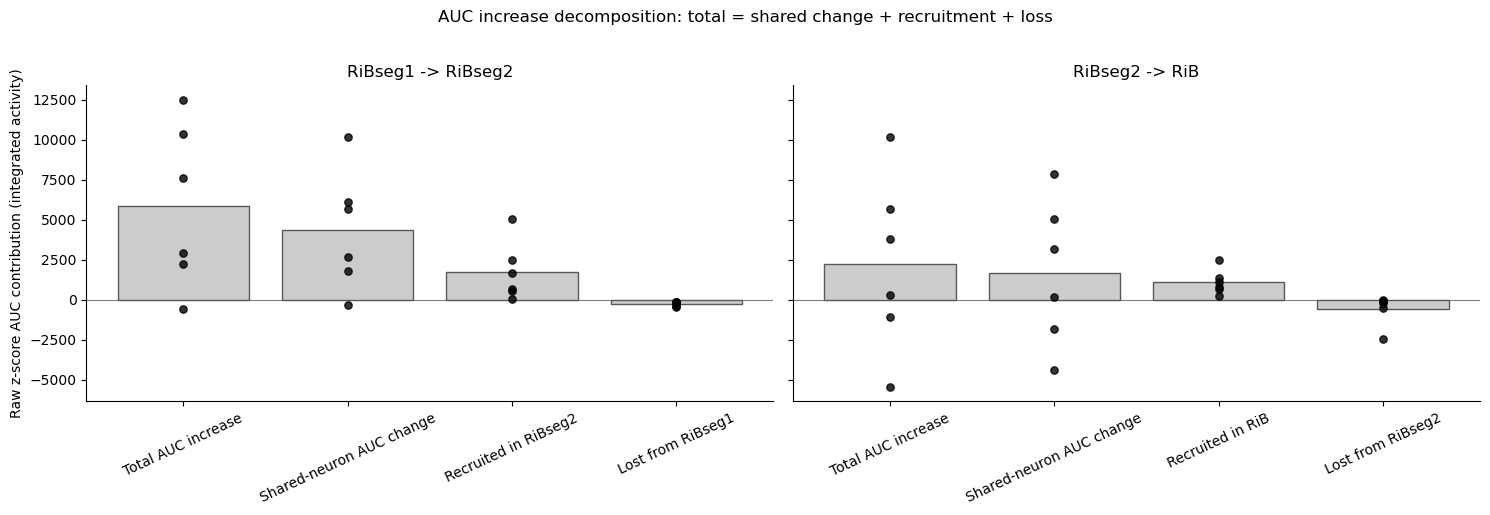

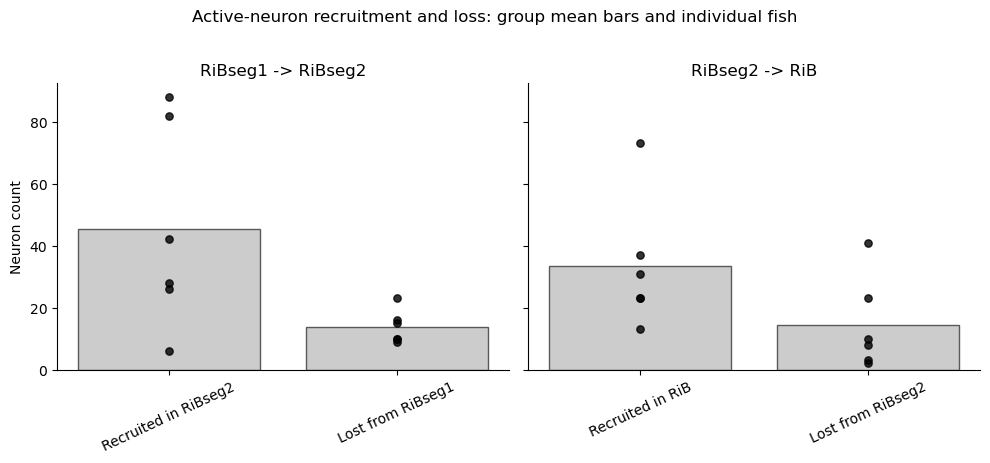

In [86]:
# Cell 11 - Per-fish raw-AUC decomposition summary (two figures only).
RAW_AUC_LABEL = 'Raw AUC (integrated activity)'
raw_auc_summary = auc_decomposition_summary.query('activity_measure == @RAW_AUC_LABEL').copy()

# Figure 1 - AUC decomposition: group mean bars plus one dot per fish.
fig, axes = plt.subplots(1, len(ACCUMULATION_AUC_PAIRS), figsize=(15, 5), sharey=True, squeeze=False)
for ax, (reference_label, larger_label) in zip(axes[0], ACCUMULATION_AUC_PAIRS):
    comparison = f'{reference_label} -> {larger_label}'
    values = raw_auc_summary[raw_auc_summary['comparison'] == comparison].set_index('fish_id').reindex(fish_ids)
    # These are additive population-AUC contributions, not per-neuron means.
    # For every fish: delta_total = shared_gain + recruitment + loss.
    auc_metrics = {
        'Total AUC increase': values['delta_total'],
        'Shared-neuron AUC change': values['shared_gain'],
        f'Recruited in {larger_label}': values['recruitment'],
        f'Lost from {reference_label}': values['loss'],
    }
    x = np.arange(len(auc_metrics))
    for position, metric_values in enumerate(auc_metrics.values()):
        ax.bar(position, metric_values.mean(), color='0.80', edgecolor='0.35', zorder=1)
        ax.scatter(np.full(len(fish_ids), position), metric_values, color='black', s=28, alpha=0.8, zorder=2)
    ax.axhline(0, color='0.5', linewidth=0.8, zorder=0)
    ax.set(xticks=x, xticklabels=list(auc_metrics), title=comparison)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].set_ylabel('Raw z-score AUC contribution (integrated activity)')
fig.suptitle('AUC increase decomposition: total = shared change + recruitment + loss', y=1.02)
fig.tight_layout()
plt.show()

# Figure 2 - Neuron numbers: group mean bars plus one dot per fish.
fig, axes = plt.subplots(1, len(ACCUMULATION_AUC_PAIRS), figsize=(10, 4.5), sharey=True, squeeze=False)
for ax, (reference_label, larger_label) in zip(axes[0], ACCUMULATION_AUC_PAIRS):
    comparison = f'{reference_label} -> {larger_label}'
    values = raw_auc_summary[raw_auc_summary['comparison'] == comparison].set_index('fish_id').reindex(fish_ids)
    count_metrics = {f'Recruited in {larger_label}': values['n_recruited'], f'Lost from {reference_label}': values['n_lost']}
    x = np.arange(len(count_metrics))
    for position, metric_values in enumerate(count_metrics.values()):
        ax.bar(position, metric_values.mean(), color='0.80', edgecolor='0.35', zorder=1)
        ax.scatter(np.full(len(fish_ids), position), metric_values, color='black', s=28, alpha=0.8, zorder=2)
    ax.set(xticks=x, xticklabels=list(count_metrics), title=comparison)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].set_ylabel('Neuron count')
fig.suptitle('Active-neuron recruitment and loss: group mean bars and individual fish', y=1.02)
fig.tight_layout()
plt.show()


,fish_id,comparison,n_ref,n_large,mean_auc_ref,mean_auc_large,delta_R,number_effect,mean_auc_effect,interaction,decomposition_verified
0,L800_f02,RiBseg1 -> RiBseg2,287,320,57.742406,75.552363,7604.685679,1905.499392,5111.457702,587.728586,True
1,L800_f03,RiBseg1 -> RiBseg2,159,149,65.081932,65.773237,-547.814779,-650.819316,109.917593,-6.913056,True
2,L800_f09,RiBseg1 -> RiBseg2,262,335,40.824971,69.248051,12501.954609,2980.222858,7446.846922,2074.884829,True
3,L800_f04,RiBseg1 -> RiBseg2,218,290,93.423886,105.900098,10344.621278,6726.519803,2719.814212,898.287263,True
4,L800_f05,RiBseg1 -> RiBseg2,219,224,59.815437,71.471693,2910.078431,299.077187,2552.719966,58.281278,True
5,L800_f07,RiBseg1 -> RiBseg2,184,200,48.604922,55.834896,2223.673637,777.678753,1330.315294,115.679591,True
6,L800_f02,RiBseg2 -> RiB,320,340,75.552363,68.033431,-1045.389521,1511.047259,-2406.058146,-150.378634,True
7,L800_f03,RiBseg2 -> RiB,149,154,65.773237,65.502927,287.238395,328.866186,-40.276239,-1.351552,True
8,L800_f09,RiBseg2 -> RiB,335,349,69.248051,77.283092,3773.702153,969.472707,2691.738866,112.490579,True
9,L800_f04,RiBseg2 -> RiB,290,280,105.900098,90.202326,-5454.377152,-1059.000981,-4552.353891,156.977720,True


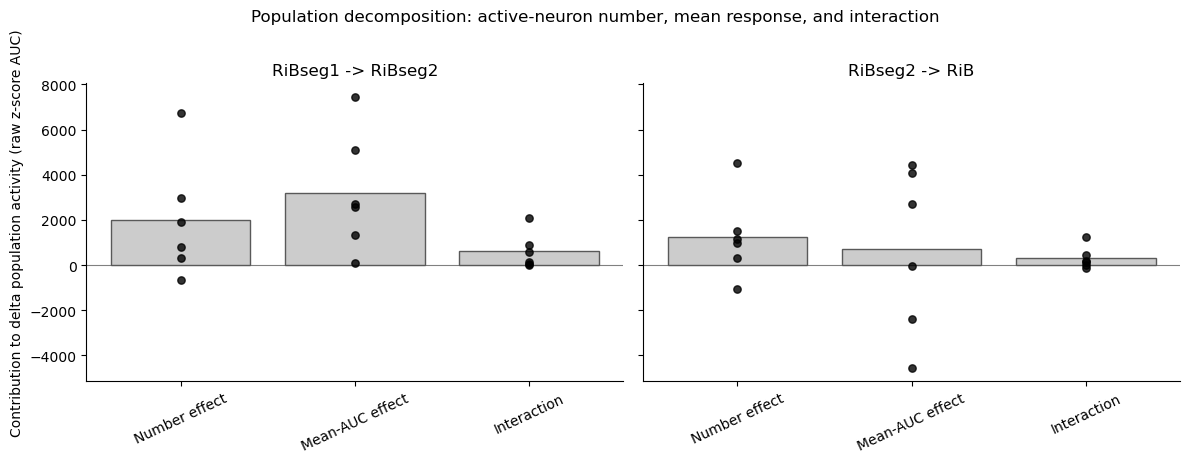

In [87]:
# Cell 12 - Population decomposition: active-neuron number versus mean active-neuron AUC.
population_decomposition_rows = []
for reference_label, larger_label in ACCUMULATION_AUC_PAIRS:
    pair_selection = at.resolve_selected_stimuli(
        [reference_label, larger_label], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_z_core'].keys(),
    )
    reference_id, larger_id = pair_selection['stimulus_ids']
    reference_label, larger_label = pair_selection['stimulus_labels']
    comparison = f'{reference_label} -> {larger_label}'
    for fish_id in fish_ids:
        active = motion_active_result['active_matrices'][fish_id]
        n_reference = int(active[reference_id].sum())
        n_larger = int(active[larger_id].sum())
        auc_totals = raw_auc_summary[(raw_auc_summary['fish_id'] == fish_id) & (raw_auc_summary['comparison'] == comparison)].iloc[0]
        mean_auc_reference = np.nan if n_reference == 0 else auc_totals['total_ref'] / n_reference
        mean_auc_larger = np.nan if n_larger == 0 else auc_totals['total_large'] / n_larger
        d_n = n_larger - n_reference
        d_a = mean_auc_larger - mean_auc_reference
        number_effect = d_n * mean_auc_reference
        mean_auc_effect = n_reference * d_a
        interaction = d_n * d_a
        delta_r = auc_totals['total_large'] - auc_totals['total_ref']
        if not np.isclose(delta_r, number_effect + mean_auc_effect + interaction, rtol=1e-8, atol=1e-10):
            raise AssertionError(f'{fish_id}, {comparison}: population decomposition failed.')
        population_decomposition_rows.append({
            'fish_id': fish_id, 'comparison': comparison, 'n_ref': n_reference, 'n_large': n_larger,
            'mean_auc_ref': mean_auc_reference, 'mean_auc_large': mean_auc_larger,
            'delta_R': delta_r, 'number_effect': number_effect, 'mean_auc_effect': mean_auc_effect,
            'interaction': interaction, 'decomposition_verified': True,
        })

population_decomposition = pd.DataFrame(population_decomposition_rows)
display(population_decomposition)

fig, axes = plt.subplots(1, len(ACCUMULATION_AUC_PAIRS), figsize=(12, 4.5), sharey=True, squeeze=False)
for ax, (reference_label, larger_label) in zip(axes[0], ACCUMULATION_AUC_PAIRS):
    comparison = f'{reference_label} -> {larger_label}'
    values = population_decomposition[population_decomposition['comparison'] == comparison].set_index('fish_id').reindex(fish_ids)
    effects = {'Number effect': values['number_effect'], 'Mean-AUC effect': values['mean_auc_effect'], 'Interaction': values['interaction']}
    x = np.arange(len(effects))
    for position, effect_values in enumerate(effects.values()):
        ax.bar(position, effect_values.mean(), color='0.80', edgecolor='0.35', zorder=1)
        ax.scatter(np.full(len(fish_ids), position), effect_values, color='black', s=28, alpha=0.8, zorder=2)
    ax.axhline(0, color='0.5', linewidth=0.8, zorder=0)
    ax.set(xticks=x, xticklabels=list(effects), title=comparison)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].set_ylabel('Contribution to delta population activity (raw z-score AUC)')
fig.suptitle('Population decomposition: active-neuron number, mean response, and interaction', y=1.02)
fig.tight_layout()
plt.show()


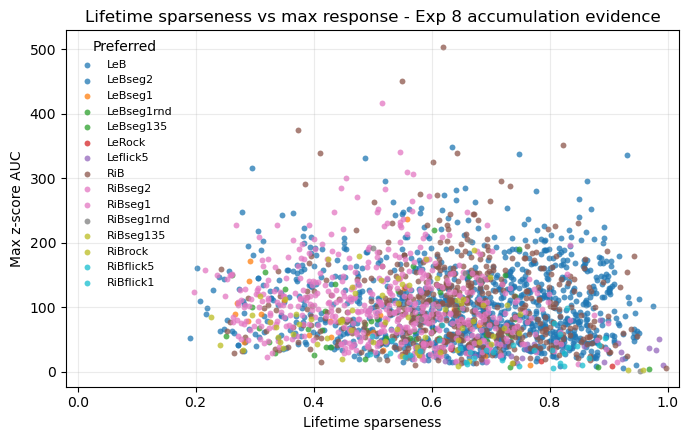

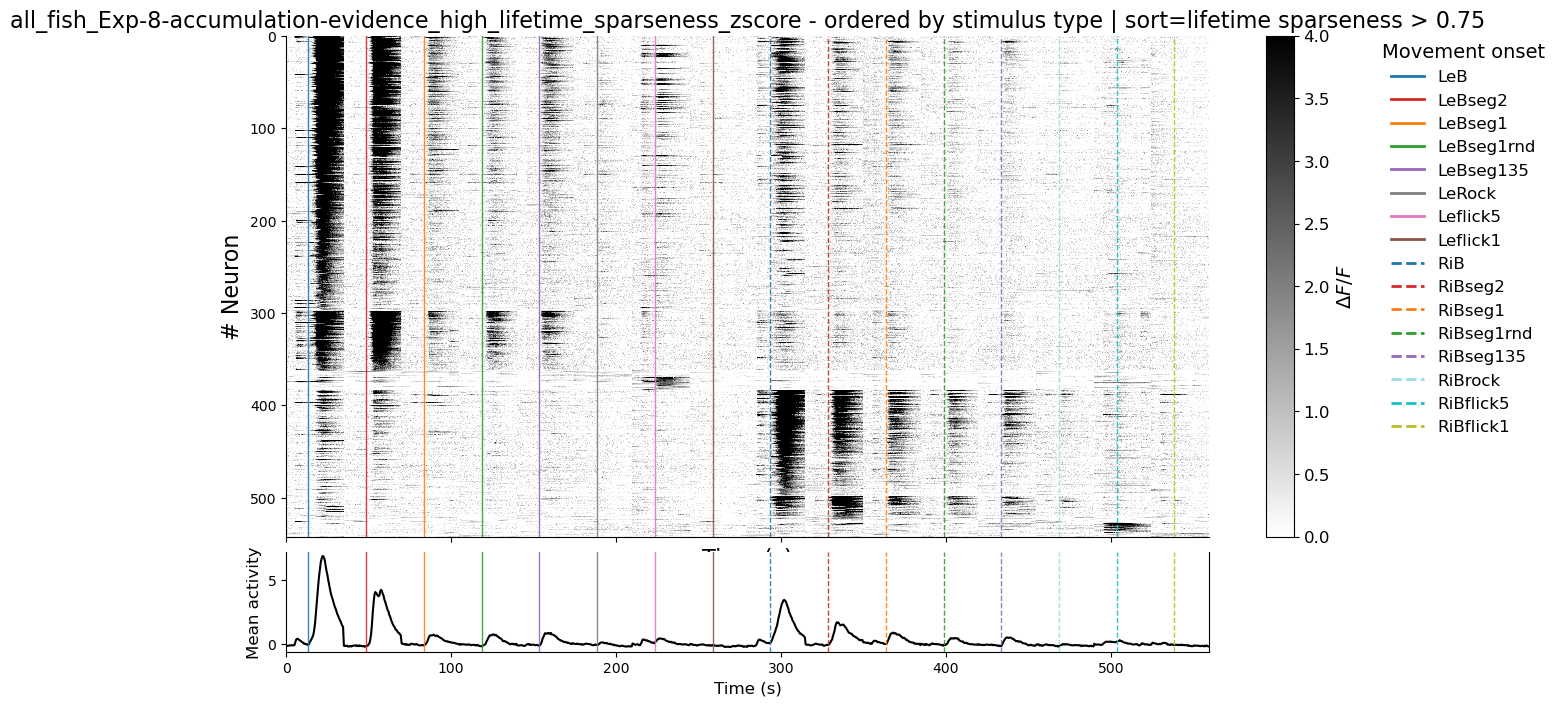

In [88]:
# Cell 08 - Lifetime sparseness and the high-sparseness z-score raster.
SPARSENESS_FIGSIZE = (7, 4.5)
RASTER_FIGSIZE = (13, 8)
SPARSENESS_STIMULI = stim_order
HIGH_LIFETIME_SPARSENESS = 0.75
HIGH_SPARSENESS_COMBINE_MODE = 'mean'
sparseness_result = rsf.plot_lifetime_sparseness_analysis(
    all_fish_data, fish_ids, reference_fish, timing, SPARSENESS_STIMULI,
    HIGH_LIFETIME_SPARSENESS, stimuli_colors, stimuli_linestyles,
    combine_mode=HIGH_SPARSENESS_COMBINE_MODE, sparseness_figsize=SPARSENESS_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE, analysis_label=settings['analysis_label'],
)


In [89]:
# Cell 09 - Optional reviewed-run report.
# Save this notebook before enabling REPORT_SETTINGS['save_report'] so the HTML includes current outputs.
notebook_path = repo_root / 'scripts' / 'calcium_analysis' / 'Exp_8_accumulation_ev' / '01_all_fish_raster.ipynb'
report_summary = pd.DataFrame([
    {
        'fish_id': fish_id,
        'kept_neurons': len(fish_data['kept_neuron_indices']),
        'detected_stimuli': len(fish_data['stimuli_ids']),
    }
    for fish_id, fish_data in all_fish_data.items()
])
report_result = rsf.save_analysis_report_run(
    settings=settings,
    report_settings=REPORT_SETTINGS,
    analysis_path=analysis_path,
    tables={'run_summary': report_summary, 'motion_active_neuron_counts': active_neuron_counts},
    notebook_path=notebook_path,
    report_name='01_all_fish_raster_exp8_report',
    extra_metadata={
        'stim_order': stim_order,
        'combine_mode': settings['combine_mode'],
        'trace_type': settings['trace_type'],
        'raster_sort_mode': settings['raster_sort_mode'],
        'all_fish_matrix_shape': flat_matrix_all_fish.shape,
    },
)
report_result


Report saving is off. Set REPORT_SETTINGS['save_report'] = True to save this run.
